importing the needed libraries loading our dataset and then checking missing values.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from wordcloud import WordCloud

import warnings
warnings.filterwarnings("ignore")

plt.figure(figsize=(10, 6))
df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")

df.head()
df.info()

df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   Unnamed: 0  1407328 non-null  int64
 1   headline    1407328 non-null  str  
 2   url         1407328 non-null  str  
 3   publisher   1407328 non-null  str  
 4   date        1407328 non-null  str  
 5   stock       1407328 non-null  str  
dtypes: int64(1), str(5)
memory usage: 64.4 MB


Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64

<Figure size 1000x600 with 0 Axes>

basic stat part the headline length , and then plot their distribution


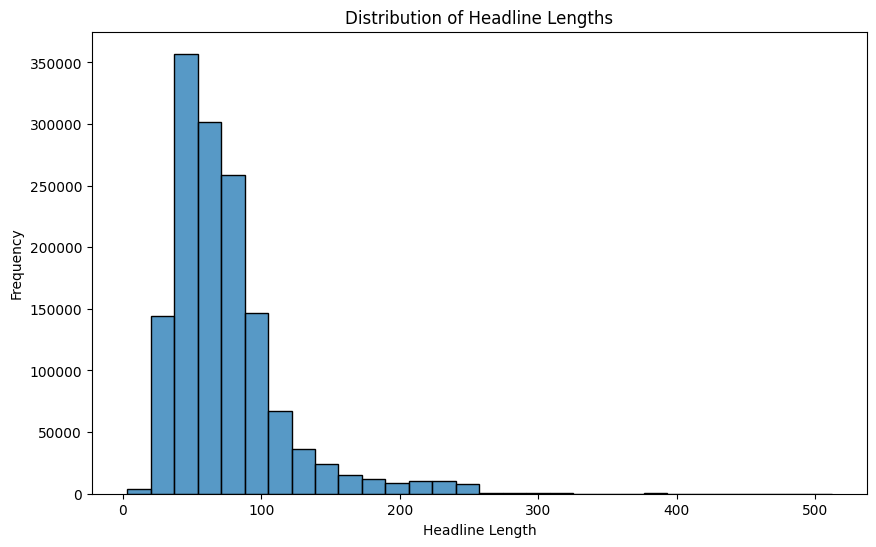

In [2]:
df["headline_length"] = df["headline"].str.len()

df["headline_length"].describe()

plt.figure(figsize=(10, 6))

sns.histplot(df["headline_length"], bins=30)

plt.title("Distribution of Headline Lengths")
plt.xlabel("Headline Length")
plt.ylabel("Frequency")

plt.show()

interpretation of the above
   Most headlines are relatively short and concise, which is common in financial journalism where headlines aim to quickly communicate important market information.


publisher's analysis part most active publishers then show it in a barchart

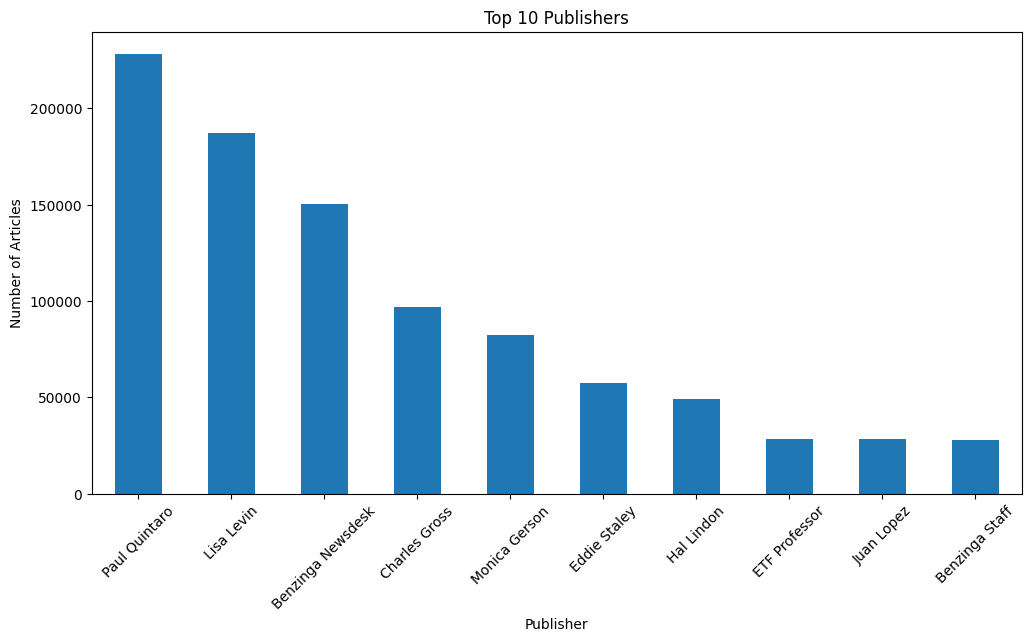

In [3]:
publisher_counts = df["publisher"].value_counts()

publisher_counts.head(10)
plt.figure(figsize=(12, 6))

publisher_counts.head(10).plot(kind="bar")

plt.title("Top 10 Publishers")
plt.xlabel("Publisher")
plt.ylabel("Number of Articles")

plt.xticks(rotation=45)

plt.show()

Interpretation

A small number of publishers contribute a large portion of the financial news articles. This suggests that certain financial media organizations dominate market-related reporting.

time series analysis part converting time column, extracting dates then plot news volume over time

In [4]:
df["date"] = pd.to_datetime(df["date"])

df["date"].head()
df["day"] = df["date"].dt.date
daily_news = df.groupby("day").size()
daily_news.head()
plt.figure(figsize=(14, 6))

daily_news.plot()

plt.title("Daily Financial News Volume")
plt.xlabel("Date")
plt.ylabel("Number of Articles")

plt.show()

ValueError: time data "2020-05-22 00:00:00" doesn't match format "%Y-%m-%d %H:%M:%S%z". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

Interpretation

The time series plot shows fluctuations in article publication frequency over time. Large spikes may correspond to significant market events such as earnings announcements, macroeconomic news, or major company developments.

NLP Keyword Analysis part Clean Headlines,Count Most Common Words, plot Most Common Words

In [ ]:
df["headline"] = df["headline"].astype(str)

headlines = df["headline"]
vectorizer = CountVectorizer(stop_words="english")

X = vectorizer.fit_transform(headlines)

word_counts = np.asarray(X.sum(axis=0)).flatten()

words = vectorizer.get_feature_names_out()

word_freq = pd.DataFrame({
    "word": words,
    "count": word_counts
})

word_freq = word_freq.sort_values(by="count", ascending=False)

word_freq.head(20)
top_words = word_freq.head(15)

plt.figure(figsize=(12, 6))

sns.barplot(x="count", y="word", data=top_words)

plt.title("Most Common Words in Headlines")

plt.show()

 Interpretation

Frequent terms such as "earnings", "stock", "market", and "price" indicate that the dataset heavily focuses on financial performance, stock analysis, and corporate announcements.

tf-idf analysis part

In [ ]:
tfidf = TfidfVectorizer(stop_words="english")

tfidf_matrix = tfidf.fit_transform(headlines)

feature_names = tfidf.get_feature_names_out()

scores = np.asarray(tfidf_matrix.mean(axis=0)).flatten()

tfidf_df = pd.DataFrame({
    "term": feature_names,
    "score": scores
})

tfidf_df = tfidf_df.sort_values(by="score", ascending=False)

tfidf_df.head(20)

word cloud visualization part ,generating Word Cloud

In [ ]:
text = " ".join(headlines)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(15, 7))

plt.imshow(wordcloud, interpolation="bilinear")

plt.axis("off")

plt.title("Word Cloud of Financial Headlines")

plt.show()

publisher's domain (if using email)

In [ ]:
df["publisher_domain"] = df["publisher"].astype(str).str.extract(r'@(.+)')

df["publisher_domain"].value_counts().head(10)